# Implementation Node

Nachdem großen Refactoring kann die `implement_transformation` Node unterschiedlich initialisiert werden. Durch eine definierte Schnittstelle und DPI können so unterschiedliche Ansätze getestet werden. Einerseits eine Implementierung eines ReAct-Agents über LangChain DeepAgents Framework, um schnelle Ergebnisse zu erhalten, ein Template-basierter Ansatz, der ein LLM nur zur Implementierung der benötigten Codeschnipsel benötigt und ein hybrider Ansatz, welcher auch schon in der Comprehension-Node verwendet wird.

## Vorbereitung
Es muss das Notebook mit den MDEAgent Modulen vorbereitet werden, sowie der gesamte Testworkspace.

In [1]:
import logging
import sys
from pathlib import Path

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
)
logger = logging.getLogger(__name__)


ROOT = Path.cwd().parent
logger.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

from mdeagent.config import Config

Config.get_instance(env_path=ROOT / ".env")

2026-09-23 15:20:36,368 [INFO] __main__: Adding /Users/lukas/Masterarbeit/agents/integrate-pi-agent to Python path for imports in kernel.


Config(MODEL=ModelConfig(API_KEY=SecretStr('**********'), BASE_URL='https://hub.nhr.fau.de/api/llmgw/v1', BASE_MODEL='gpt-oss-120b', CODING_MODEL='gpt-oss-120b', REQUEST_TIMEOUT=120, MAX_RETRIES=2), LANGFUSE=LangFuseConfig(SECRET_KEY=SecretStr('**********'), PUBLIC_KEY=SecretStr('**********'), BASE_URL='http://localhost:3000'), VARIABLES=VariablesConfig(UPDATED_FILE_INDEX=13, TRANSFORMATION_CLASS_NAME='MDEAgentTransformation'), AGENT_CONTROL=AgentControlConfig(WORKFLOW_MAX_ITERATIONS=5, TRANSFORMATION_IMPLEMENTATION_STRATEGY='pi'))

Zunächst müssen die Test-Dateien vorbereitet werden.

In [2]:
TEST_FOLDER = ROOT / ".mdeagent-tests"
SETUP_FILES = TEST_FOLDER / "setup"
TEST_EXECUTION_FOLDER = TEST_FOLDER / "test-executions"

if not TEST_FOLDER.exists():
    logger.error(f"Creating test execution folder at {TEST_FOLDER}")
    raise RuntimeError(
        f"Test execution folder {TEST_FOLDER} did not exist and was created. "
        "Please re-run the notebook."
    )

from datetime import UTC, datetime

WORKSPACE = TEST_EXECUTION_FOLDER / datetime.now(tz=UTC).strftime("%Y-%m-%d_%H-%M-%S")
WORKSPACE.mkdir(parents=True, exist_ok=False)

In [3]:
# Read all the java files from the setup folder and copy them into the Transformation Plan
from mdeagent.comprehension.plan import (
    FileTransformationPlanParser,
    TransformationPlan,
)

transformation_plan = TransformationPlan.parse(
    FileTransformationPlanParser(WORKSPACE / "TRANSFORMATION.md")
)
transformation_plan.update_iteration(0)


def read_model_implementations(path: Path) -> str:
    """
    Reads the model implementation files from the given path and returns their content as a string.
    """
    if not path.exists() or not path.is_dir():
        raise FileNotFoundError(
            f"The specified path {path} does not exist or is not a directory."
        )

    model_files_content = []
    for file in path.glob("*.java"):
        with open(file, "r") as f:
            model_files_content.append(f.read())

    return "\n".join(model_files_content)


transformation_plan.update_model_implementation(
    source_model_implementation=read_model_implementations(SETUP_FILES / "metamodels" / "Families"),
    target_model_implementation=read_model_implementations(SETUP_FILES / "metamodels" / "Persons"),
)
transformation_plan.update_package_information(
    source_model_package="org.example.families",
    target_model_package="org.example.persons",
)

2026-09-23 15:20:36,460 [WARNING] mdeagent.comprehension.plan: Error occurred while parsing transformation plan: Transformation plan file not found at /Users/lukas/Masterarbeit/agents/integrate-pi-agent/.mdeagent-tests/test-executions/2026-09-23_13-20-36/TRANSFORMATION.md
2026-09-23 15:20:36,461 [INFO] mdeagent.comprehension.plan: Creating initial transformation plan with default values.


## Initialisierung und Aufbau

In [4]:
from mdeagent.evaluation import (
    EvaluationExecutor,
    FileExistenceEvaluation,
    FileExistenceSchema,
    JavaCompilationEvaluation,
    JavaCompilationSchema,
    ToolInstalledEvaluation,
    ToolInstalledSchema,
    WorkspaceStructureEvaluation,
    WorkspaceStructureSchema,
)

executor = EvaluationExecutor(
        evaluations={
            "workspace_structure": {
                "evaluation": WorkspaceStructureEvaluation(),
                "evaluation_schema": WorkspaceStructureSchema,
            },
            "tools_installed": {
                "evaluation": ToolInstalledEvaluation(),
                "evaluation_schema": ToolInstalledSchema,
            },
            "file_existence": {
                "evaluation": FileExistenceEvaluation(),
                "evaluation_schema": FileExistenceSchema,
            },
            "java_compilation": {
                "evaluation": JavaCompilationEvaluation(),
                "evaluation_schema": JavaCompilationSchema,
            },
        }
    )

In [5]:
from pathlib import Path

from mdeagent.implementation.agent import build_implementation_graph

config = Config.get_instance()

implementation_agent = build_implementation_graph(
    executor,
    workspace_path=WORKSPACE,
    implementation_strategy=config.AGENT_CONTROL.TRANSFORMATION_IMPLEMENTATION_STRATEGY,
)

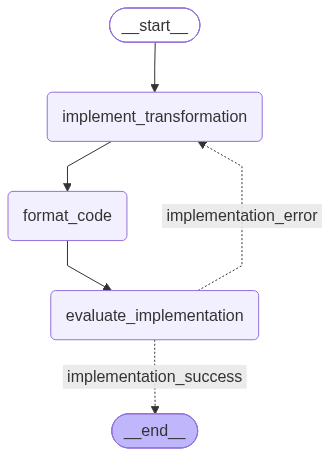

In [6]:
graph = implementation_agent.compile()
graph

## Ausführung
Der Graph kann anschließend mit `ainvoke` ausgeführt werden. Hierbei wird getestet, ob die erstellten Dateien auch wirklich kompilierbar sind.

In [7]:
from mdeagent.implementation.state import ImplementationState
from mdeagent.implementation.types import TransformationClass

input_state = ImplementationState(
    transformation_plan=transformation_plan.to_dict(),
    transformation_class=TransformationClass(
        name="FamiliesToPersons", package="org.example.families2persons", path=WORKSPACE / "FamiliesToPersons.java"
    ),
    task_specification="Implement the transformation from Families to Persons according to the provided transformation plan.",
    iteration=0.
)

output = await graph.ainvoke(input=input_state, version="v2")

NotImplementedError: PI strategy is not yet implemented.